In [2]:
import os
import sys
sys.path.append("../../")

from biked_commons.design_evaluation.design_evaluation import *
from biked_commons.conditioning import conditioning
from biked_commons.resource_utils import datasets_path
from biked_commons.benchmark_models import benchmarking_utils
from biked_commons.benchmark_models.generative_modeling_utils import sample_continuous
from biked_commons.design_evaluation.score_report import ScoreReportDashboard

c:\Users\Lyler\mambaforge\envs\bike-bench-cuda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
cond_idx = 3
folder = f"results/unconditional/cond_{cond_idx}"

model = "AGG-LS"

result_tens = torch.load(os.path.join(folder, model, "result_tens.pt"))

data = data_loading.load_bike_bench_train()
result_df = pd.DataFrame(result_tens, columns=data.columns)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
result_tens = result_tens.to(device)

In [14]:
result_tens.shape

torch.Size([55, 90])

In [15]:
evaluations_list = get_standard_evaluations(device, aesthetics_mode="Embedding")

evaluator, requirement_names, requirement_types = construct_tensor_evaluator(evaluations_list, data.columns)

condition = benchmarking_utils.get_condition_by_idx(cond_idx)


In [16]:
eval_scores = evaluator(result_tens, condition)
constraint_scores = eval_scores[:, np.array(requirement_types) == 0]
constraint_satisfied = constraint_scores <= 0
all_constraint_satisfied = constraint_satisfied.all(axis=1)

tensor([ 467.5735, 1122.6567,  467.0225, 1105.8164,  442.3887, 1130.6108,
        1233.5953, 1222.6689,  533.7281,  403.7477, 1162.5040, 1079.2057,
        1129.0107, 1217.0663,  344.2498,  577.7222,  496.1291, 1087.4481,
         390.2295, 1086.6503, 1088.9867,  344.7440,  388.9963, 1116.8291,
        1140.2363, 1110.9935, 1081.4718, 1115.5034, 1238.6046, 1163.4382,
        1149.1527,  449.2822, 1237.8358,  551.0211, 1105.1171, 1153.2189,
        1249.8837, 1150.8912,  214.7745, 1233.9243,  549.5546, 1195.3744,
        1167.0552, 1225.1321, 1155.8788,  421.4360, 1123.0963,  436.4876,
         335.0336,  404.1017,  460.4471, 1122.8798, 1162.6918, 1246.4066,
        1209.3143], device='cuda:0')
tensor([ 458.9419,  468.3414,  439.4654,  428.1243,  422.6563,  481.6013,
         922.5638,  986.7827,  511.9729,  347.4076,  559.8184,  357.8204,
         485.3963, 1019.9193,  295.0363,  487.4395,  463.9894,  374.5828,
         322.2531,  373.7488,  375.2710,  311.4572,  371.9430,  425.9117,
 

In [17]:
valid_result_df = result_df.iloc[all_constraint_satisfied.cpu().detach().numpy()]

In [18]:
valid_result_df.shape

(7, 90)

In [19]:
evaluator(torch.tensor(valid_result_df.to_numpy()).to(device), condition).cpu().detach().numpy()

tensor([467.5735, 467.0225, 442.3887, 344.2498, 577.7222, 496.1291, 436.4876],
       device='cuda:0')
tensor([458.9419, 439.4654, 422.6563, 295.0363, 487.4395, 463.9894, 417.8231],
       device='cuda:0')
tensor([249.9875, 300.1416, 287.4530, 187.7322, 161.7742, 212.9678,  -0.5577],
       device='cuda:0')
tensor([ 49.1059,  49.2469,  49.0471, 100.0991,  63.5285,  12.8303,  45.6743],
       device='cuda:0')
tensor([393.4430, 425.5011, 397.9448, 392.3569, 316.5142, 613.8855, 514.2349],
       device='cuda:0')
tensor([ 0.1134,  0.2296,  0.1585,  0.6421,  0.3209, -0.0962,  0.1555],
       device='cuda:0')
tensor([1.0048, 0.9565, 0.9452, 1.1245, 1.0983, 1.2369, 1.5719],
       device='cuda:0')


array([[ 5.45520902e-01,  1.87913361e+01,  1.33533859e+00,
         1.67377701e+01,  1.81714935e+01,  3.97741795e-04,
         1.72716789e+01,  1.76977396e-01,  1.54043615e-01,
         1.82521224e-01, -7.06556797e-01, -3.09217262e+00,
        -1.52710754e+02, -4.20000000e+01, -1.37289246e+02,
        -2.33199997e+02, -4.66145020e+02, -2.70700226e+01,
         0.00000000e+00, -1.41659698e+02, -4.89308289e+02,
        -9.83705139e+01, -3.01617126e+01, -1.99402161e+02,
        -9.99999680e+08, -2.09366094e+04, -1.60148590e+02,
        -3.88000000e+02, -1.14963989e+01,  0.00000000e+00,
        -1.72834015e+01, -7.50924683e+00, -8.51138306e+00,
        -4.30489120e+01, -2.28807373e+01, -5.00000000e-01],
       [ 5.19526362e-01,  1.89689217e+01,  2.45591927e+00,
         8.41611481e+00,  1.79501572e+01,  8.98241997e-04,
         1.53832035e+01,  4.68932390e-02,  4.67488170e-02,
         9.03710723e-02, -3.06776762e-01, -1.87859035e+00,
        -9.10427856e+01, -5.00000000e+01, -2.28957214e+

In [4]:
from biked_commons.rendering import rendering
renderer = rendering.RenderingEngine(number_rendering_servers = 1, server_init_timeout_seconds=120)

Using java as the Java binary


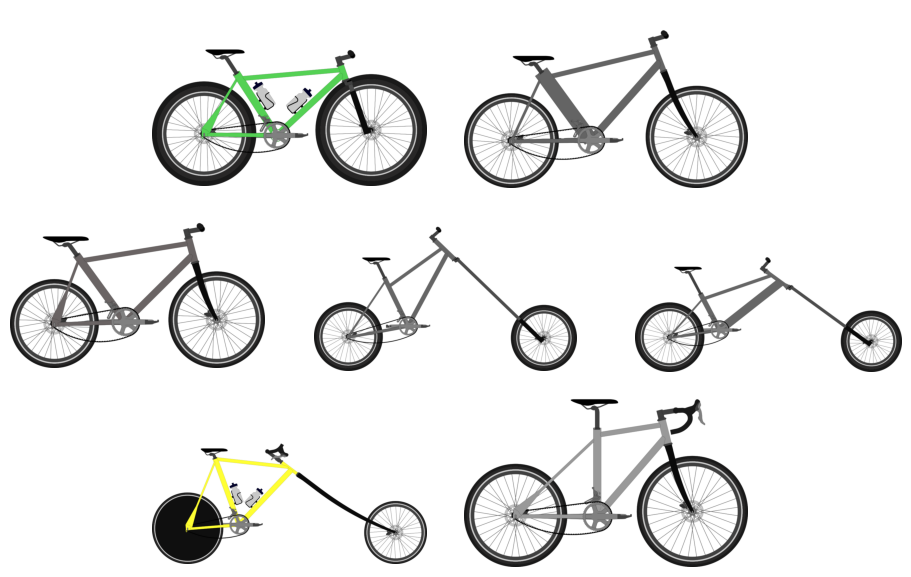

In [21]:
# usage example:
from biked_commons.rendering.visualize_grid import plot_bike_grid
from matplotlib import pyplot as plt

fig = plot_bike_grid(renderer, valid_result_df)
plt.show()

In [5]:
cond_idx = 0
folder = f"results/unconditional/cond_{cond_idx}"

model = "CTGAN"

result_tens = torch.load(os.path.join(folder, model, "result_tens.pt"))

data = data_loading.load_bike_bench_train()
result_df = pd.DataFrame(result_tens, columns=data.columns)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
result_tens = result_tens.to(device)

In [6]:
result_df

,CS textfield,BB textfield,Stack,Head angle,Head tube length textfield,Seat stay junction0,Seat tube length,Seat angle,DT Length,FORK0R,...,Handlebar style OHCLASS: 2,Stem kind OHCLASS: 0,Stem kind OHCLASS: 1,Stem kind OHCLASS: 2,Fork type OHCLASS: 0,Fork type OHCLASS: 1,Fork type OHCLASS: 2,Seat tube type OHCLASS: 0,Seat tube type OHCLASS: 1,Seat tube type OHCLASS: 2
0,416.090302,67.806396,546.938660,72.321335,191.913483,46.000443,508.175110,73.776276,657.382568,44.540184,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,415.761078,75.476158,665.874512,75.355461,154.789261,46.485840,618.296753,76.340950,686.456482,44.933102,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,429.843292,67.902618,514.956482,73.392609,116.130875,44.513287,477.548889,69.588585,657.346619,44.810604,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,409.183350,75.221786,488.260864,72.463982,149.576050,48.122665,401.504669,71.962646,675.321167,45.672386,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,448.223480,73.803207,448.152954,71.543434,133.975998,49.462360,553.675781,70.392738,673.082397,44.389679,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,405.698517,69.473503,633.635803,67.176971,146.053513,45.634495,522.407166,74.213409,656.622498,44.989315,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
996,519.771179,46.703922,545.108093,72.939766,90.143692,89.259895,468.956177,79.964317,651.439697,42.045086,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
997,405.480286,66.272697,494.371094,72.993584,149.972961,46.022964,588.110229,73.678833,693.260559,44.631454,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
998,447.434418,159.123047,432.950409,62.842812,143.210907,46.256096,530.202576,79.037552,661.635010,42.936295,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [10]:
from tqdm import tqdm, trange
#make directory if needed
os.makedirs(f"results/unconditional/cond_{cond_idx}/{model}/images", exist_ok=True)

#loop over results, render each one, save to a file

# for i, row in tqdm(result_df.iterrows()):
for i in trange(len(result_df)):
    row = result_df.iloc[i]
    res = renderer.render_clip(row)
    svg = res.image_bytes
    with open(f"results/unconditional/cond_{cond_idx}/{model}/images/{i}.svg", "wb") as f:
        f.write(svg)


  4%|▍         | 38/1000 [03:57<1:42:11,  6.37s/it]c:\Users\Lyler\mambaforge\envs\bike-bench-cuda\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
 10%|▉         | 96/1000 [10:45<1:41:50,  6.76s/it]c:\Users\Lyler\mambaforge\envs\bike-bench-cuda\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
 11%|█         | 111/1000 [12:30<1:45:49,  7.14s/it]c:\Users\Lyler\mambaforge\envs\bike-bench-cuda\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
 16%|█▌        | 160/1000 [18:03<1:38:32,  7.04s/it]c:\Users\Lyler\mambaforge\envs\bike-bench-cuda\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
 2

InternalError: Rendering request failed <Response [500]>

In [12]:
import cairosvg
#loop over svg files (loading from fileand convert to png
for i in trange(len(result_df)):
    with open(f"results/unconditional/cond_{cond_idx}/{model}/images/{i}.svg", "rb") as f:
        svg = f.read()
    png = cairosvg.svg2png(bytestring=svg)
    with open(f"results/unconditional/cond_{cond_idx}/{model}/images/{i}.png", "wb") as f:
        f.write(png)


 22%|██▏       | 217/1000 [04:07<14:52,  1.14s/it]


FileNotFoundError: [Errno 2] No such file or directory: 'results/unconditional/cond_0/CTGAN/images/217.svg'

In [ ]:
evaluator, requirement_names, requirement_types = construct_tensor_evaluator([ValidationEvaluator(device=device)], data.columns)

condition = benchmarking_utils.get_condition_by_idx(cond_idx)



In [44]:
StandardEvaluations = [
    UsabilityEvaluator(device=device),
    AeroEvaluator(device=device),
    ErgonomicsEvaluator(device=device, penalize_constraints=False, constraints_only=False),
    AestheticsEvaluator(mode="Embedding", batch_size=64, device=device),
    StructuralEvaluator(device=device),
    ValidationEvaluator(device=device),
    FrameValidityEvaluator(device=device)
]
evaluator, requirement_names, requirement_types = construct_tensor_evaluator(StandardEvaluations, data.columns)

condition = benchmarking_utils.get_condition_by_idx(cond_idx)

In [45]:
eval_scores = evaluator(result_tens, condition)
constraint_scores = eval_scores[:, np.array(requirement_types) == 0]
constraint_satisfied = constraint_scores <= 0
all_constraint_satisfied = constraint_satisfied.all(axis=1)

In [46]:
print(torch.sum(all_constraint_satisfied[:216]))

tensor(0, device='cuda:0')


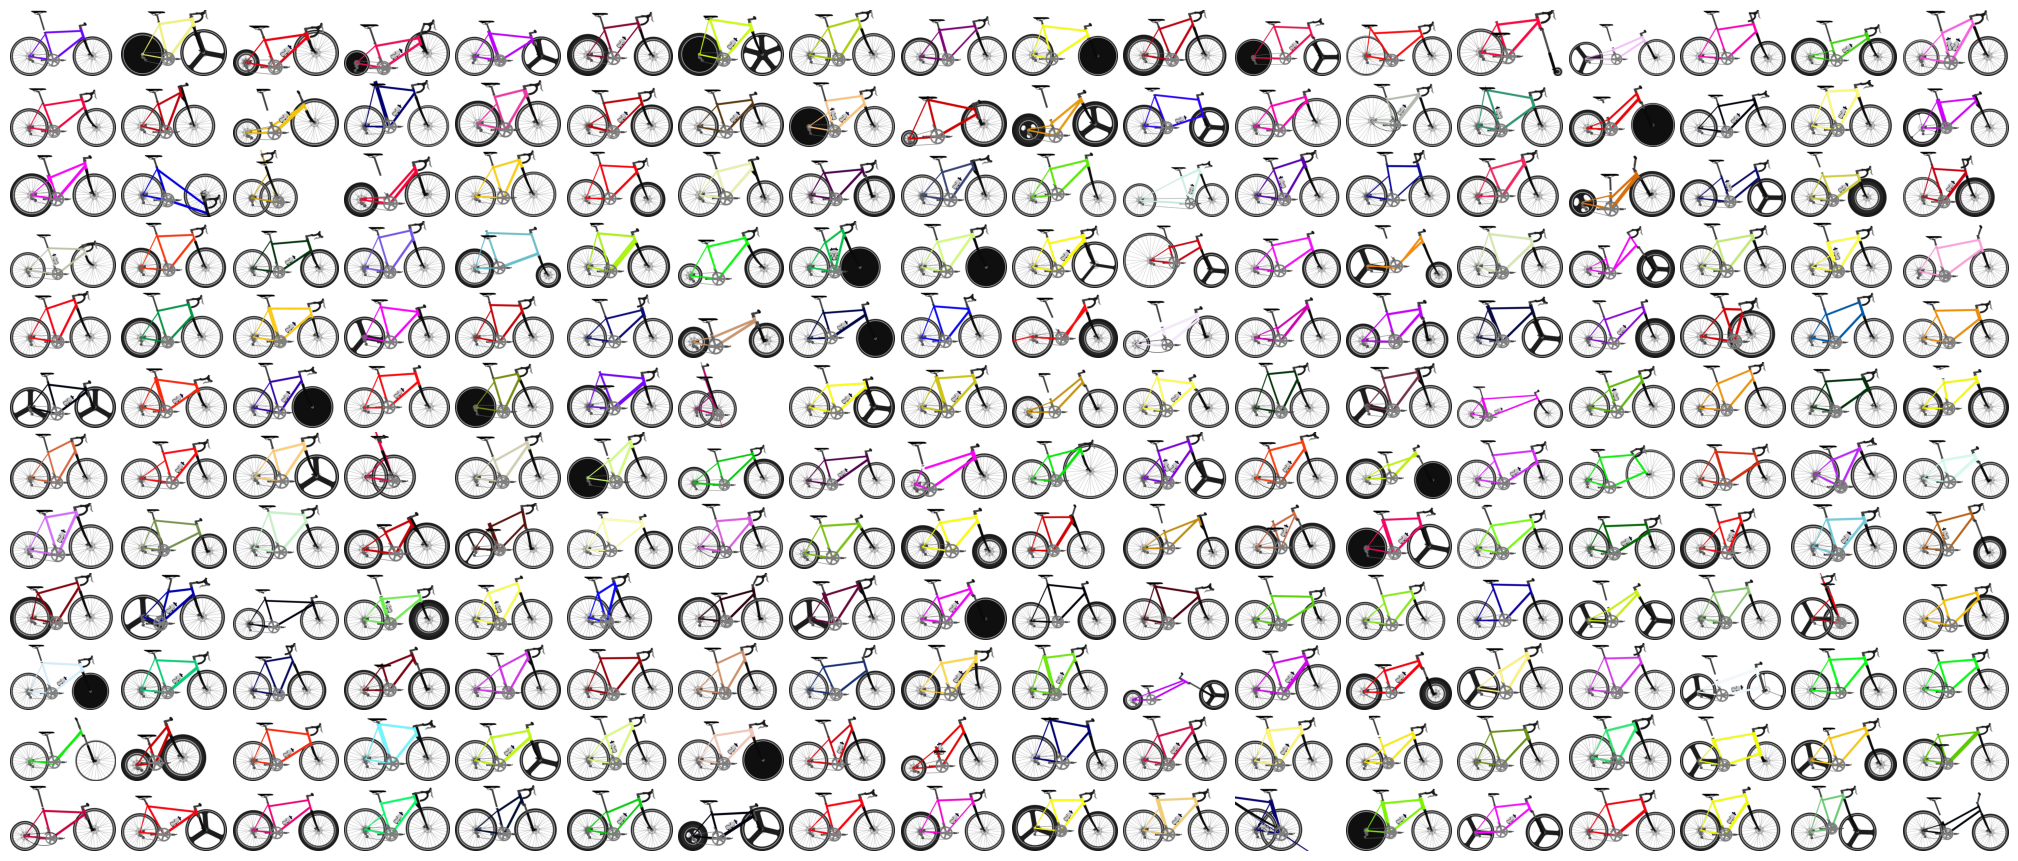

In [33]:
import os, glob
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib as mpl

folder = f"results/unconditional/cond_{cond_idx}/{model}/images"
paths = sorted(glob.glob(os.path.join(folder, "*.png")),
               key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
               if os.path.splitext(os.path.basename(p))[0].isdigit() else float("inf"))

im0 = Image.open(paths[0]).convert("RGB")
aspect = im0.width / im0.height

nrows, ncols = 12, 18
gap_px = 4   # try 2–8 pixels

fig_w = 20
fig_h = fig_w / (aspect * (ncols / nrows))

# IMPORTANT: turn off constrained_layout so subplots_adjust takes effect
fig, axs = plt.subplots(
    nrows, ncols, figsize=(fig_w, fig_h),
    constrained_layout=False,  # <—
    facecolor="white"
)

# convert pixel gap -> wspace/hspace fractions
dpi = fig.dpi
tile_w_px = fig_w * dpi / ncols
tile_h_px = fig_h * dpi / nrows
wspace = gap_px / tile_w_px
hspace = gap_px / tile_h_px

# zero outer margins + apply the gaps
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=wspace, hspace=hspace)

axes = axs.ravel()
for ax in axes:
    ax.set_axis_off()

for i, ax in enumerate(axes):
    if i >= len(paths): break
    ax.imshow(Image.open(paths[i]).convert("RGB"))  # aspect='equal' keeps shapes

plt.show()


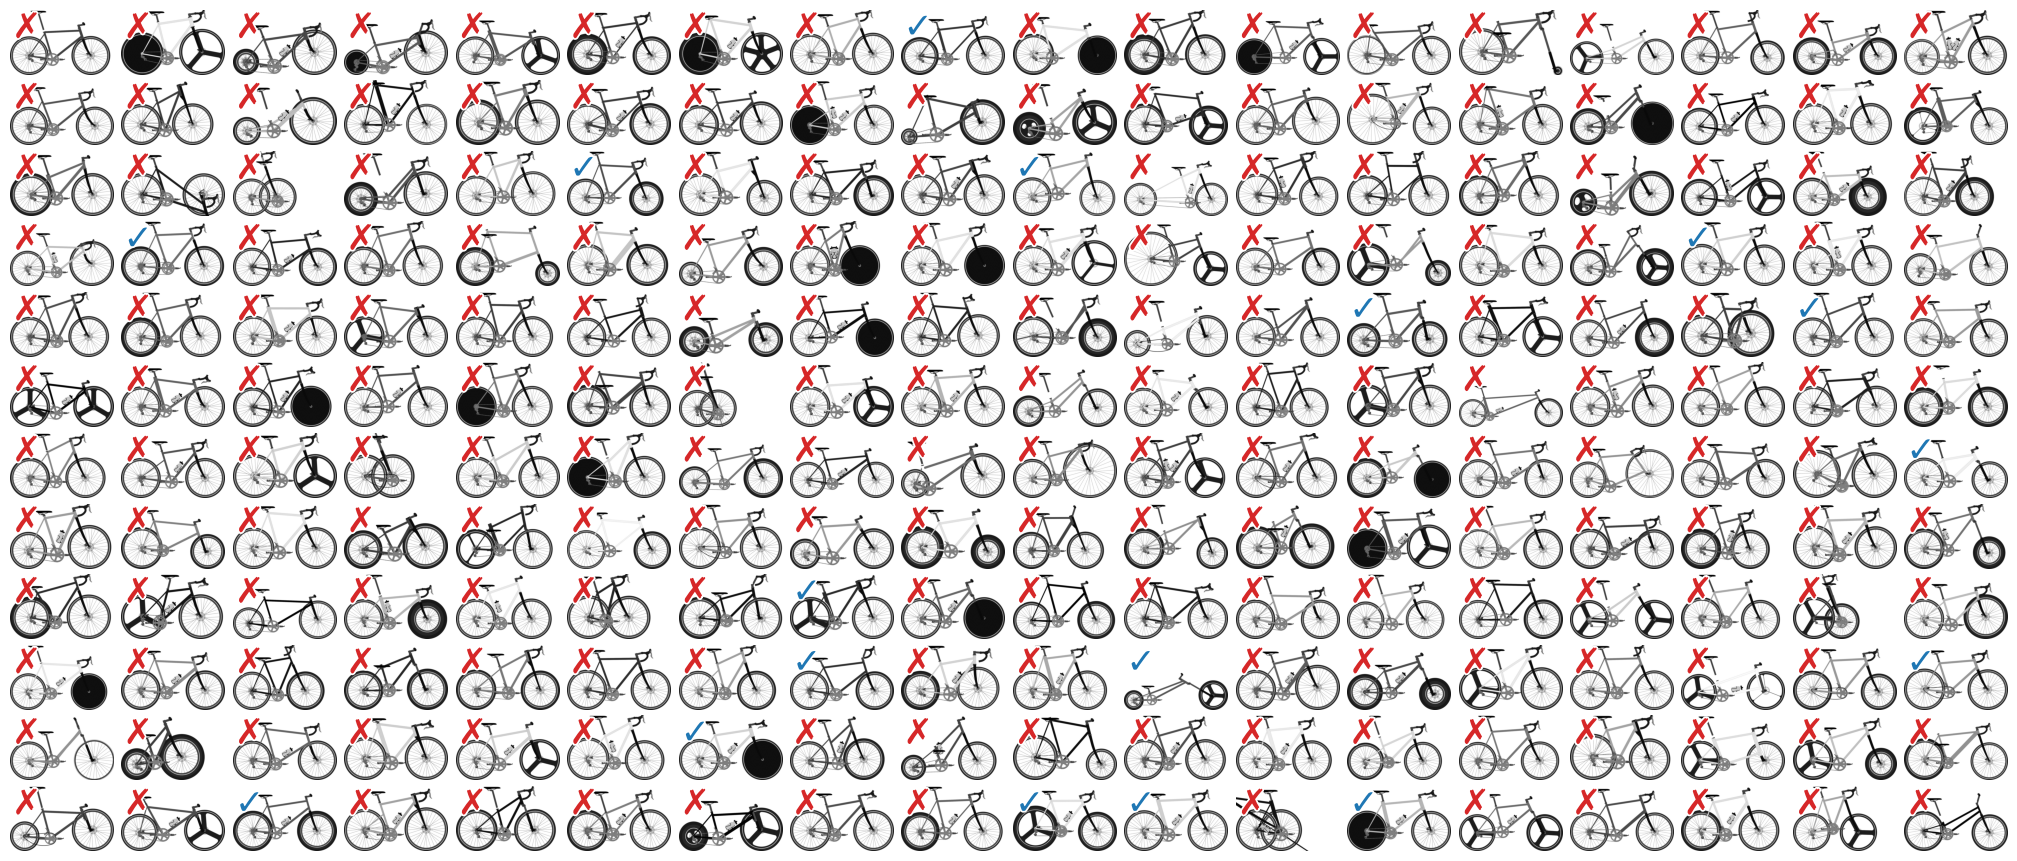

In [38]:
import os, glob
from PIL import Image
import torch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

folder = f"results/unconditional/cond_{cond_idx}/{model}/images"
paths = sorted(glob.glob(os.path.join(folder, "*.png")),
               key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
               if os.path.splitext(os.path.basename(p))[0].isdigit() else float("inf"))

# ---- validity flags (torch tensor -> bool numpy) ----
valid_flags = torch.as_tensor(all_constraint_satisfied).detach().cpu().numpy().astype(bool).ravel()

# ---- probe aspect, grid + gap config (same as before) ----
im0 = Image.open(paths[0]).convert("RGB")
aspect = im0.width / im0.height

nrows, ncols = 12, 18
gap_px = 6  # a few pixels

fig_w = 20
fig_h = fig_w / (aspect * (ncols / nrows))

fig, axs = plt.subplots(
    nrows, ncols, figsize=(fig_w, fig_h),
    constrained_layout=False,  # ensure subplots_adjust works
    facecolor="white"
)

dpi = fig.dpi
tile_w_px = fig_w * dpi / ncols
tile_h_px = fig_h * dpi / nrows
wspace = gap_px / tile_w_px
hspace = gap_px / tile_h_px
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=wspace, hspace=hspace)

axes = axs.ravel()
for ax in axes:
    ax.set_axis_off()

limit = min(len(paths), nrows * ncols, len(valid_flags))
# text size in points so that its height ≈ 1/4 of tile height in pixels
icon_size_pt = (tile_h_px * 0.5) * 72.0 / dpi
outline = [pe.withStroke(linewidth=2.5, foreground="white")]

for i in range(limit):
    ax = axes[i]
    # grayscale background
    im = Image.open(paths[i]).convert("L")
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)

    # overlay icon at top-left in axes coords
    if valid_flags[i]:
        char, color = "✓", "tab:blue"
    else:
        char, color = "✗", "tab:red"

    ax.text(
        0.02, 0.98, char,
        transform=ax.transAxes, ha="left", va="top",
        fontsize=icon_size_pt, color=color, fontweight="bold",
        path_effects=outline, zorder=5
    )

# optional title / save
# fig.suptitle(f"{model} – cond {cond_idx} (✓ valid, ✗ invalid)", fontsize=10)

plt.show()


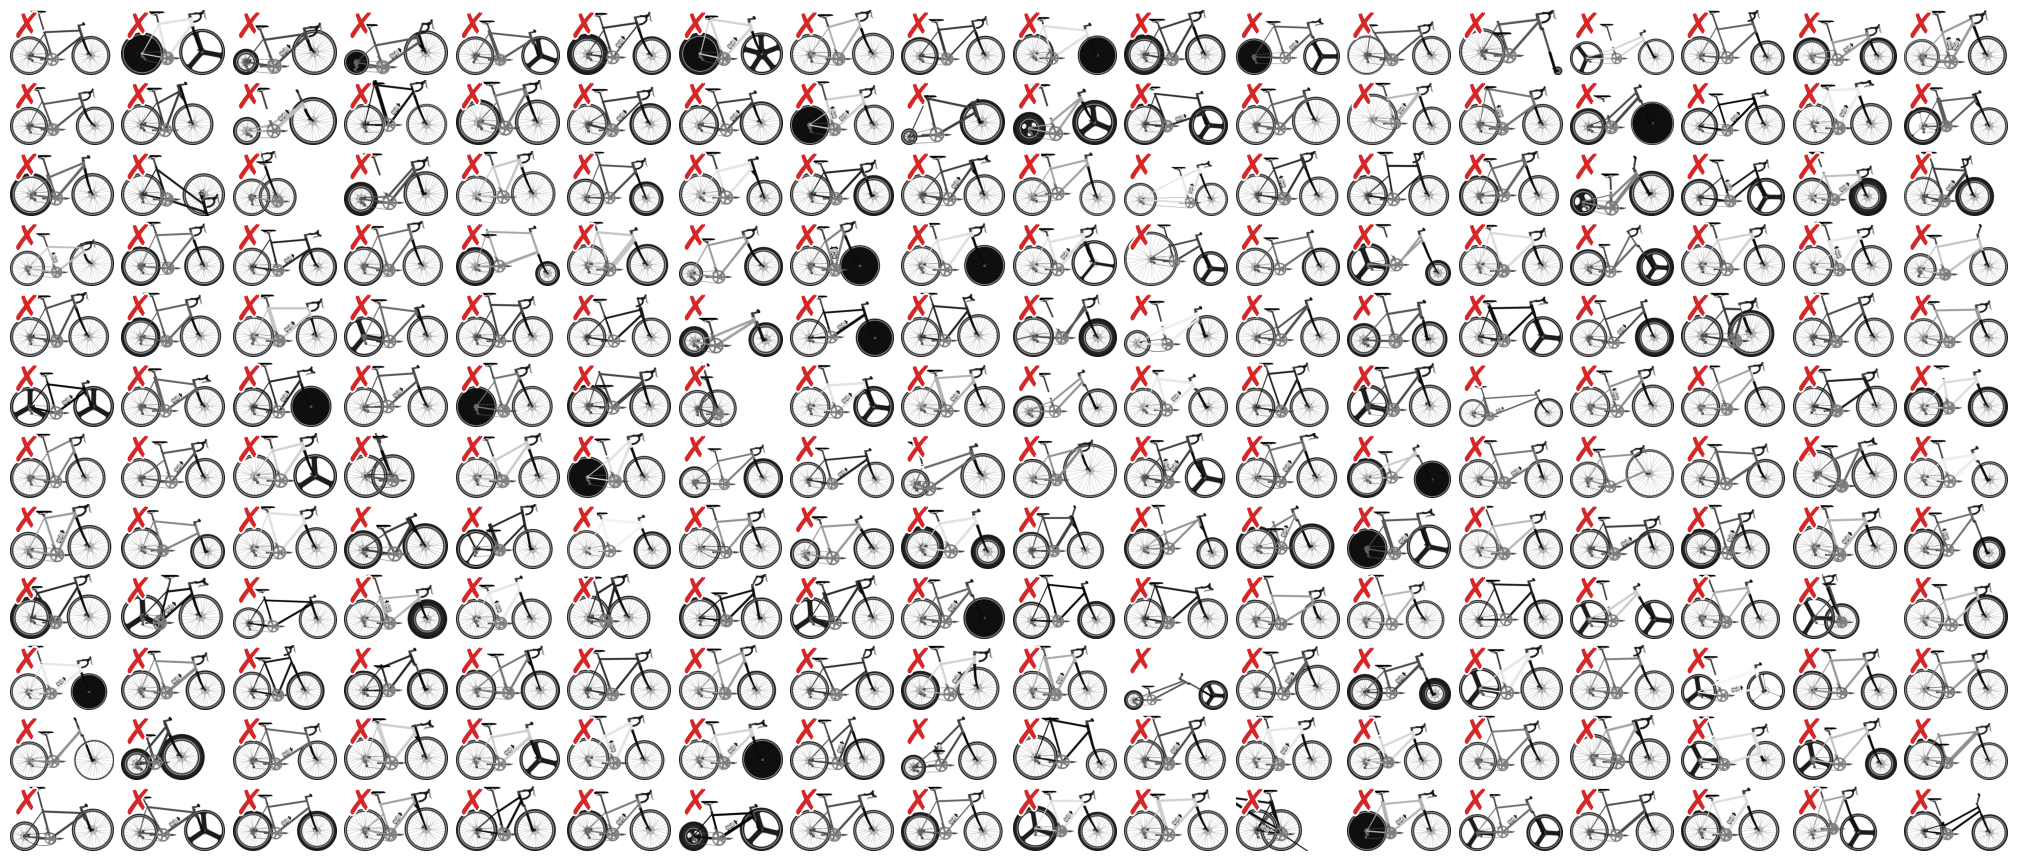

In [47]:
import os, glob
from PIL import Image
import torch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

folder = f"results/unconditional/cond_{cond_idx}/{model}/images"
paths = sorted(glob.glob(os.path.join(folder, "*.png")),
               key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
               if os.path.splitext(os.path.basename(p))[0].isdigit() else float("inf"))

# ---- validity flags (torch tensor -> bool numpy) ----
valid_flags = torch.as_tensor(all_constraint_satisfied).detach().cpu().numpy().astype(bool).ravel()

# ---- probe aspect, grid + gap config (same as before) ----
im0 = Image.open(paths[0]).convert("RGB")
aspect = im0.width / im0.height

nrows, ncols = 12, 18
gap_px = 6  # a few pixels

fig_w = 20
fig_h = fig_w / (aspect * (ncols / nrows))

fig, axs = plt.subplots(
    nrows, ncols, figsize=(fig_w, fig_h),
    constrained_layout=False,  # ensure subplots_adjust works
    facecolor="white"
)

dpi = fig.dpi
tile_w_px = fig_w * dpi / ncols
tile_h_px = fig_h * dpi / nrows
wspace = gap_px / tile_w_px
hspace = gap_px / tile_h_px
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=wspace, hspace=hspace)

axes = axs.ravel()
for ax in axes:
    ax.set_axis_off()

limit = min(len(paths), nrows * ncols, len(valid_flags))
# text size in points so that its height ≈ 1/4 of tile height in pixels
icon_size_pt = (tile_h_px * 0.5) * 72.0 / dpi
outline = [pe.withStroke(linewidth=2.5, foreground="white")]

for i in range(limit):
    ax = axes[i]
    # grayscale background
    im = Image.open(paths[i]).convert("L")
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)

    # overlay icon at top-left in axes coords
    if valid_flags[i]:
        char, color = "✓", "tab:blue"
    else:
        char, color = "✗", "tab:red"

    ax.text(
        0.02, 0.98, char,
        transform=ax.transAxes, ha="left", va="top",
        fontsize=icon_size_pt, color=color, fontweight="bold",
        path_effects=outline, zorder=5
    )

# optional title / save
# fig.suptitle(f"{model} – cond {cond_idx} (✓ valid, ✗ invalid)", fontsize=10)

plt.show()
